# Analyse du marché Airbnb

Projet Data Analyst

Objectif : identifier les quartiers les plus rentables pour un investissement locatif Airbnb.

Technologies utilisées :

- Python
- Pandas
- SQLAlchemy
- MySQL
- Matplotlib


## 1. Import des librairies

In [48]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt

from src.database import get_engine

## 2. Connexion à la base de données

In [49]:
engine = get_engine()

query = "SELECT * FROM listings"

df = pd.read_sql(query, engine)

df.head()

,id,name,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Boroughs,0.0,40.64749,-73.97237,348.58,149,1,9.0,2018,0
1,2595,Skylit Midtown Castle,2845,Jennifer,Bronx,0.0,40.75362,-73.98377,302.33,225,1,45.0,2019,0
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,0.0,40.80902,-73.9419,65.92,150,3,0.0,0,0
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Boroughs,0.0,40.68514,-73.95976,72.59,89,1,270.0,2019,5
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,0.0,40.79851,-73.94399,115.18,80,10,9.0,2018,0


## 3. Exploration des données

In [50]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48895 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   neighbourhood_group             48895 non-null  str    
 4   neighbourhood                   48895 non-null  str    
 5   latitude                        48895 non-null  float64
 6   longitude                       48895 non-null  float64
 7   room_type                       48895 non-null  str    
 8   price                           48895 non-null  float64
 9   minimum_nights                  48895 non-null  int64  
 10  number_of_reviews               48895 non-null  int64  
 11  reviews_per_month               48895 non-null  float64
 12  calculated_host_listings_count  48895 non-n

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.0,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,0.0,40.728949,225.850493,152.720687,7.029962,23.274466,1603.361284,1.054443
std,1.098311e+07,7.861097e+07,0.0,0.054530,101.218506,240.154170,20.510550,44.550582,815.654155,1.640373
min,2.539000e+03,2.438000e+03,0.0,40.499790,50.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,9.471945e+06,7.822033e+06,0.0,40.690100,138.090000,69.000000,1.000000,1.000000,2016.000000,0.000000
50%,1.967728e+07,3.079382e+07,0.0,40.723070,225.990000,106.000000,3.000000,5.000000,2019.000000,0.000000
75%,2.915218e+07,1.074344e+08,0.0,40.763115,313.920000,175.000000,5.000000,24.000000,2019.000000,2.000000
max,3.648724e+07,2.743213e+08,0.0,40.913060,400.000000,10000.000000,1250.000000,629.000000,2019.000000,59.000000


## 4. Data Cleaning

In [51]:
# supprimer des doublons
df = df.drop_duplicates()

# remplacer les valeurs manquantes
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

# supprimer des prix aberrants
df = df[df["price"] >= 0]
df = df[df["price"] < 1000]

df.head()

,id,name,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Boroughs,0.0,40.64749,-73.97237,348.58,149,1,9.0,2018,0
1,2595,Skylit Midtown Castle,2845,Jennifer,Bronx,0.0,40.75362,-73.98377,302.33,225,1,45.0,2019,0
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,0.0,40.80902,-73.9419,65.92,150,3,0.0,0,0
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Boroughs,0.0,40.68514,-73.95976,72.59,89,1,270.0,2019,5
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,0.0,40.79851,-73.94399,115.18,80,10,9.0,2018,0


## 5. Prix moyen par quartier

In [52]:
prix_moyen = (
    df.groupby("neighbourhood")["price"]
    .mean()
    .sort_values(ascending=False)
)

prix_moyen

neighbourhood
Manhattan        226.664753
Brooklyn         226.402167
Bronx            226.100872
Boroughs         224.998476
Queens           223.748299
Staten Island    214.148133
Name: price, dtype: float64

Visualisation

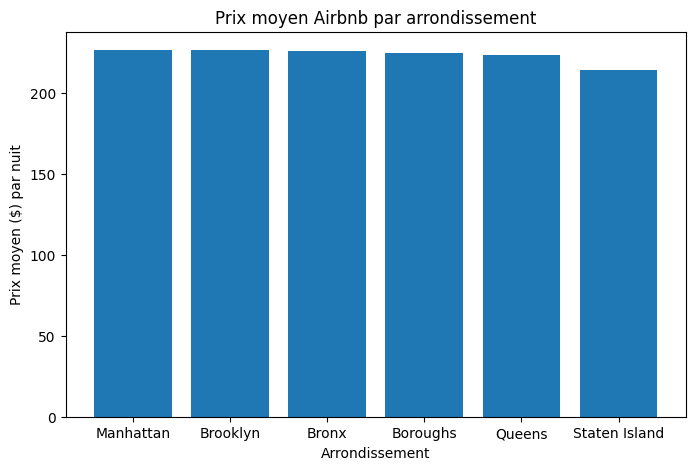

In [64]:
plt.figure(figsize=(8,5))

plt.bar(prix_moyen.index, prix_moyen.values)

plt.title("Prix moyen Airbnb par arrondissement")
plt.xlabel("Arrondissement")
plt.ylabel("Prix moyen ($) par nuit")

plt.show()

## 6. Taux d'occupation estimé
Pour calculer le taux d'occupation, il suffit d'analyser la colonne "avaibility_365" qui représente les disponibilés sur un an de chaque annonce airbnb. On part du fait que moins un logement est disponible, logiquement plus il est occupé sur un an. D'où la formule :
taux_occupation = (365 - availability_365) / 365

In [62]:
df["taux_occupation"] = (365 - df["availability_365"]) / 365

occupation = (
    df.groupby("neighbourhood")["taux_occupation"]
    .mean()
    .sort_values(ascending=False)
)

occupation

neighbourhood
Manhattan        0.997925
Brooklyn         0.997524
Bronx            0.997488
Queens           0.997097
Staten Island    0.995862
Boroughs         0.995488
Name: taux_occupation, dtype: float64

Visualisation

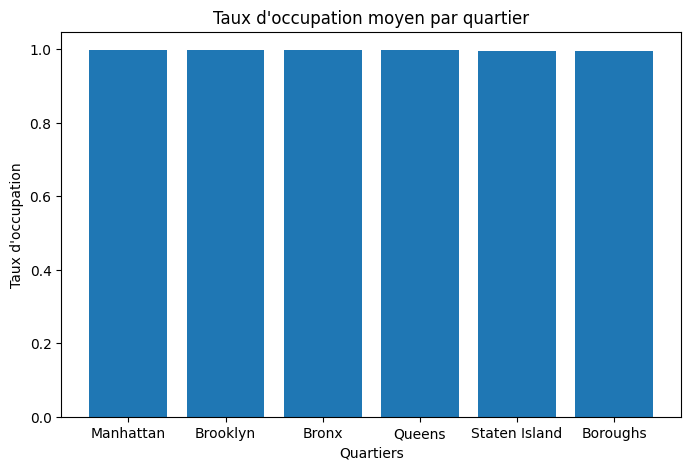

In [65]:
plt.figure(figsize=(8,5))

plt.bar(occupation.index, occupation.values)

plt.title("Taux d'occupation moyen par quartier")
plt.xlabel("Quartiers")
plt.ylabel("Taux d'occupation")

plt.show()

## 8. Quartiers les plus chers

In [56]:
quartiers_chers = (
    df.groupby("neighbourhood")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

quartiers_chers

neighbourhood
Manhattan    226.664753
Brooklyn     226.402167
Bronx        226.100872
Boroughs     224.998476
Queens       223.748299
Name: price, dtype: float64

Visualisation

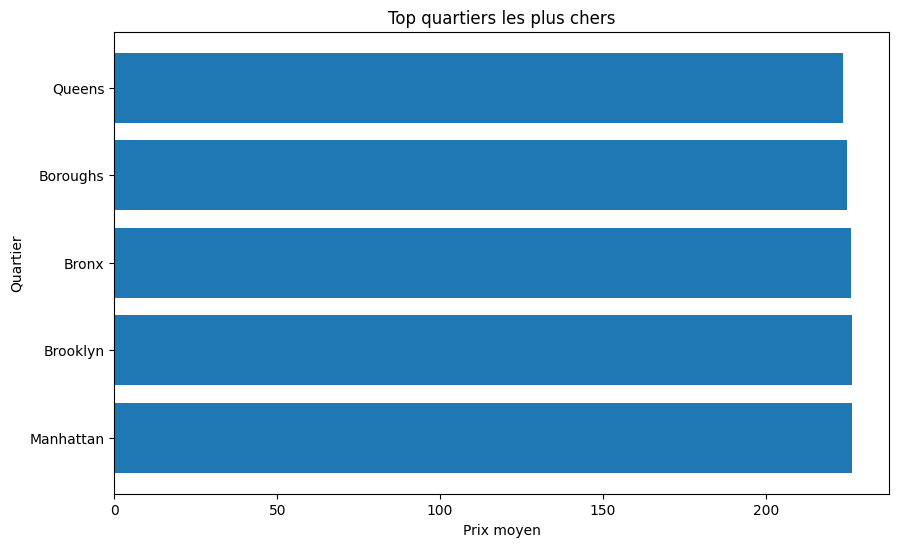

In [66]:
plt.figure(figsize=(10,6))

plt.barh(quartiers_chers.index, quartiers_chers.values)

plt.title("Top quartiers les plus chers")
plt.xlabel("Prix moyen")
plt.ylabel("Quartier")

plt.show()

## 9. Quartiers les plus demandés
Pour identifier les quartiers les plus demandés, il suffit d'identifier les quartiers qui ont le plus d'avis.

In [71]:
quartiers_demandes = (
    df.groupby("neighbourhood")["number_of_reviews"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

quartiers_demandes

neighbourhood
Manhattan    126353
Brooklyn     104162
Bronx         75007
Queens        25527
Boroughs      11135
Name: number_of_reviews, dtype: int64

Visualisation

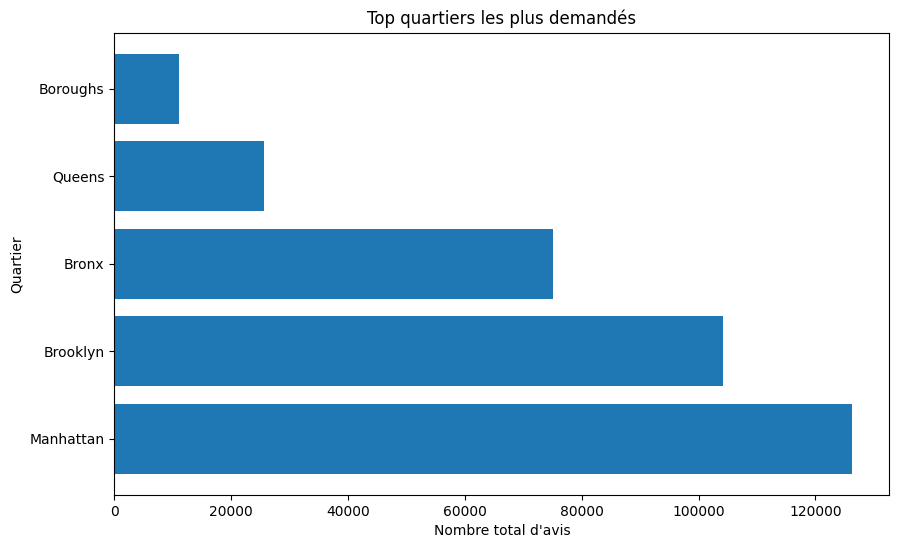

In [72]:
plt.figure(figsize=(10,6))

plt.barh(quartiers_demandes.index, quartiers_demandes.values)

plt.title("Top quartiers les plus demandés")
plt.xlabel("Nombre total d'avis")
plt.ylabel("Quartier")

plt.show()

## 10. Estimation du revenu

Pour estimer le revenu annuel il suffit d'effectuer le produit : 
prix × 365 × taux_occupation

In [73]:
df["revenu_estime"] = df["price"] * 365 * df["taux_occupation"]

revenu = (
    df.groupby("neighbourhood")["revenu_estime"]
    .mean()
    .sort_values(ascending=False)
)

revenu

neighbourhood
Manhattan        82561.808768
Brooklyn         82430.560394
Bronx            82319.017029
Boroughs         81753.435943
Queens           81428.020150
Staten Island    77841.992905
Name: revenu_estime, dtype: float64

Visualisation

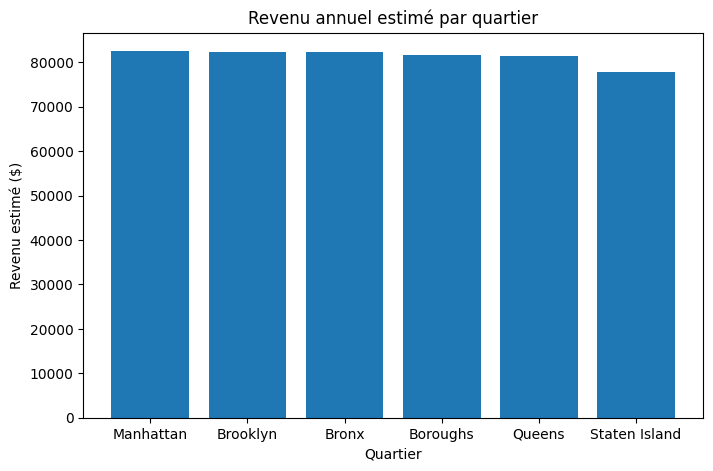

In [74]:
plt.figure(figsize=(8,5))

plt.bar(revenu.index, revenu.values)

plt.title("Revenu annuel estimé par quartier")
plt.xlabel("Quartier")
plt.ylabel("Revenu estimé ($)")

plt.show()

## Conclusion

Les zones les plus intéressantes pour un investissement doivent combiner :

- un prix moyen élevé
- un taux d'occupation élevé
- une forte demande

A travers les différentes visualisations, nous pouvons identififier Manhattan et Brooklyn comme les deux meilleures zones pour un investissement rentable.